# Evaluación Test-Blind ASOCA
**Fase 2 — Segmentación Coronaria con ResU-Net**

Evalúa `model_best.pth` sobre los 10 casos ciegos de ASOCA.
Métricas: Dice, Sensibilidad, Precisión, Hausdorff Distance 95%
Visualización: árbol coronario 3D (Marching Cubes)

In [1]:
# ── Celda 1: Imports ──────────────────────────────────────────────
import os, json, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.ndimage import zoom
from scipy.spatial.distance import directed_hausdorff
import pandas as pd
import sys

sys.path.insert(0, '/media/mrsmile/IA/tesis')
from models.resunet_segmentation import ResUNetSegmentation

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# ── Celda 2: Rutas y configuración ───────────────────────────────
BASE        = '/media/mrsmile/IA/tesis'
MEMMAP_VOL  = os.path.join(BASE, 'data/processed/memmap/volumes')
MEMMAP_META = os.path.join(BASE, 'data/processed/memmap/meta')
MEMMAP_MASK = os.path.join(BASE, 'data/processed/memmap/masks')
MEMMAP_MMETA= os.path.join(BASE, 'data/processed/memmap/masks_meta')
SPLIT_JSON  = os.path.join(BASE, 'data/metadata/data_split.json')
CKPT_DIR    = os.path.join(BASE, 'runs/checkpoints/segmentation')
OUT_DIR     = os.path.join(BASE, 'reportes/evaluation')
os.makedirs(OUT_DIR, exist_ok=True)

PATCH_SIZE  = (128, 128, 128)
STRIDE      = (64, 64, 64)
THRESHOLD   = 0.5

with open(SPLIT_JSON) as f:
    split = json.load(f)

# Limpiar extensiones .nii.gz si existen
raw_cases  = split['asoca']['test_blind']
test_cases = [c.replace('.nii.gz', '').replace('.nii', '') for c in raw_cases]

print(f'Casos test_blind: {len(test_cases)}')
for c in test_cases:
    print(f'  {c}')

Casos test_blind: 10
  asoca_diseased_7
  asoca_diseased_15
  asoca_diseased_10
  asoca_diseased_16
  asoca_diseased_2
  asoca_diseased_8
  asoca_normal_10
  asoca_normal_19
  asoca_normal_8
  asoca_normal_20


In [3]:
# ── Celda 3: Cargar modelo ────────────────────────────────────────
runs = sorted(glob.glob(os.path.join(CKPT_DIR, '*')))
print('Runs disponibles:')
for r in runs:
    best = os.path.join(r, 'model_best.pth')
    exists = 'OK' if os.path.exists(best) else 'NO'
    print(f'  [{exists}] {os.path.basename(r)}')

CKPT_PATH = None
for r in reversed(runs):
    best = os.path.join(r, 'model_best.pth')
    if os.path.exists(best):
        CKPT_PATH = best
        break

print(f'\nCheckpoint: {CKPT_PATH}')

model = ResUNetSegmentation(in_channels=1, out_channels=1, base=32).to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    best_epoch = ckpt.get('epoch', '?')
    best_dice  = ckpt.get('best_dice', 0.0)
elif isinstance(ckpt, dict) and 'state_dict' in ckpt:
    model.load_state_dict(ckpt['state_dict'])
    best_epoch = ckpt.get('epoch', '?')
    best_dice  = ckpt.get('best_dice', 0.0)
else:
    model.load_state_dict(ckpt)
    best_epoch = '?'
    best_dice  = 0.0

model.eval()
print(f'Modelo cargado -- epoca {best_epoch} -- val Dice: {best_dice}')


Runs disponibles:
  [NO] seg_20260307_1232
  [OK] seg_20260307_1310
  [NO] seg_20260307_1325
  [OK] seg_20260307_1329

Checkpoint: /media/mrsmile/IA/tesis/runs/checkpoints/segmentation/seg_20260307_1329/model_best.pth
Modelo cargado -- epoca ? -- val Dice: 0.0


In [4]:
# Verificar que el modelo cargó bien
total_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {total_params:,}')
print(f'Parametros encoder: {sum(p.numel() for n,p in model.named_parameters() if n.startswith("e"))}')
print(f'Parametros decoder: {sum(p.numel() for n,p in model.named_parameters() if not n.startswith("e"))}')

Parametros totales: 5,686,465
Parametros encoder: 3556640
Parametros decoder: 2129825


In [5]:
# ── Celda 4: Funciones auxiliares ────────────────────────────────

def load_volume(case_id):
    """Carga volumen y máscara desde memmap."""
    meta_path = os.path.join(MEMMAP_META, f'{case_id}.json')
    vol_path  = os.path.join(MEMMAP_VOL,  f'{case_id}.dat')
    with open(meta_path) as f:
        meta = json.load(f)
    vol = np.memmap(vol_path, dtype=meta['dtype'], mode='r',
                    shape=tuple(meta['shape']))
    vol = np.array(vol)  # copiar a RAM

    mmeta_path = os.path.join(MEMMAP_MMETA, f'{case_id}.json')
    mask_path  = os.path.join(MEMMAP_MASK,  f'{case_id}.dat')
    with open(mmeta_path) as f:
        mmeta = json.load(f)
    mask = np.memmap(mask_path, dtype=mmeta['dtype'], mode='r',
                     shape=tuple(mmeta['shape']))
    mask = np.array(mask)
    return vol, mask


def sliding_window_inference(model, volume, patch_size, stride, device, threshold=0.5):
    """Inferencia sliding window con overlap, promedia probabilidades."""
    D, H, W = volume.shape
    pd, ph, pw = patch_size
    sd, sh, sw = stride

    pred_sum   = np.zeros((D, H, W), dtype=np.float32)
    count_map  = np.zeros((D, H, W), dtype=np.float32)

    # Padding si el volumen es menor que el parche
    pad_d = max(0, pd - D)
    pad_h = max(0, ph - H)
    pad_w = max(0, pw - W)
    if pad_d + pad_h + pad_w > 0:
        volume = np.pad(volume, ((0,pad_d),(0,pad_h),(0,pad_w)), mode='reflect')

    D2, H2, W2 = volume.shape

    d_starts = list(range(0, max(1, D2-pd+1), sd))
    if d_starts[-1] + pd < D2: d_starts.append(D2 - pd)
    h_starts = list(range(0, max(1, H2-ph+1), sh))
    if h_starts[-1] + ph < H2: h_starts.append(H2 - ph)
    w_starts = list(range(0, max(1, W2-pw+1), sw))
    if w_starts[-1] + pw < W2: w_starts.append(W2 - pw)

    vol_padded = np.pad(volume, ((0,0),(0,0),(0,0)))
    pred_sum_p = np.zeros_like(vol_padded, dtype=np.float32)
    count_p    = np.zeros_like(vol_padded, dtype=np.float32)

    with torch.no_grad():
        for d in d_starts:
            for h in h_starts:
                for w in w_starts:
                    patch = volume[d:d+pd, h:h+ph, w:w+pw]
                    t = torch.tensor(patch[None,None], dtype=torch.float32).to(device)
                    logit = model(t)
                    prob  = torch.sigmoid(logit).cpu().numpy()[0,0]
                    pred_sum_p[d:d+pd, h:h+ph, w:w+pw] += prob
                    count_p   [d:d+pd, h:h+ph, w:w+pw] += 1.0

    count_p = np.maximum(count_p, 1e-8)
    avg_prob = pred_sum_p / count_p
    # Recortar al tamaño original
    avg_prob = avg_prob[:D, :H, :W]
    pred_bin = (avg_prob >= threshold).astype(np.uint8)
    return pred_bin, avg_prob


def compute_metrics(pred, gt):
    """Calcula Dice, Sensibilidad, Precisión y HD95."""
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()

    dice  = (2*tp) / (2*tp + fp + fn + 1e-8)
    sens  = tp / (tp + fn + 1e-8)
    prec  = tp / (tp + fp + 1e-8)

    # Hausdorff 95% — sobre coordenadas de superficie
    pred_pts = np.argwhere(pred)
    gt_pts   = np.argwhere(gt)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        hd95 = float('nan')
    else:
        # Subsample para velocidad (máx 5000 puntos)
        if len(pred_pts) > 5000:
            idx = np.random.choice(len(pred_pts), 5000, replace=False)
            pred_pts = pred_pts[idx]
        if len(gt_pts) > 5000:
            idx = np.random.choice(len(gt_pts), 5000, replace=False)
            gt_pts = gt_pts[idx]
        d1 = directed_hausdorff(pred_pts, gt_pts)[0]
        d2 = directed_hausdorff(gt_pts, pred_pts)[0]
        hd95 = max(d1, d2)

    return {'dice': dice, 'sensitivity': sens, 'precision': prec, 'hd95': hd95}

print('Funciones cargadas ✅')

Funciones cargadas ✅


In [6]:
import os, json

# Ver qué case_ids tiene el split
with open('/media/mrsmile/IA/tesis/data/metadata/data_split.json') as f:
    split = json.load(f)
print("test_blind en split:")
for c in split['asoca']['test_blind']:
    print(f"  '{c}'")

# Ver qué archivos existen en meta
print("\nArchivos en meta/:")
meta_dir = '/media/mrsmile/IA/tesis/data/processed/memmap/meta'
for f in sorted(os.listdir(meta_dir))[:10]:
    print(f"  {f}")

test_blind en split:
  'asoca_diseased_7.nii.gz'
  'asoca_diseased_15.nii.gz'
  'asoca_diseased_10.nii.gz'
  'asoca_diseased_16.nii.gz'
  'asoca_diseased_2.nii.gz'
  'asoca_diseased_8.nii.gz'
  'asoca_normal_10.nii.gz'
  'asoca_normal_19.nii.gz'
  'asoca_normal_8.nii.gz'
  'asoca_normal_20.nii.gz'

Archivos en meta/:
  asoca_diseased_1.json
  asoca_diseased_10.json
  asoca_diseased_11.json
  asoca_diseased_12.json
  asoca_diseased_13.json
  asoca_diseased_14.json
  asoca_diseased_15.json
  asoca_diseased_16.json
  asoca_diseased_17.json
  asoca_diseased_18.json


In [7]:
# ── Celda 5: Inferencia en todos los casos test_blind ─────────────
results = []
predictions = {}  # guardamos para visualización

for case_id in test_cases:
    print(f'\n🔍 Procesando {case_id}...')
    vol, mask_gt = load_volume(case_id)
    print(f'   Volumen: {vol.shape} | GT positivos: {mask_gt.sum()} vóxeles')

    pred_bin, pred_prob = sliding_window_inference(
        model, vol, PATCH_SIZE, STRIDE, DEVICE, THRESHOLD
    )

    metrics = compute_metrics(pred_bin, mask_gt)
    metrics['case_id'] = case_id
    metrics['type'] = 'diseased' if 'diseased' in case_id else 'normal'
    results.append(metrics)
    predictions[case_id] = {'pred': pred_bin, 'prob': pred_prob,
                             'gt': mask_gt, 'vol': vol}

    print(f'   Dice: {metrics["dice"]:.4f} | '
          f'Sens: {metrics["sensitivity"]:.4f} | '
          f'Prec: {metrics["precision"]:.4f} | '
          f'HD95: {metrics["hd95"]:.2f}')

print('\n✅ Inferencia completada')


🔍 Procesando asoca_diseased_7...
   Volumen: (233, 505, 505) | GT positivos: 29641.0 vóxeles
   Dice: 0.7477 | Sens: 0.7575 | Prec: 0.7381 | HD95: 178.75

🔍 Procesando asoca_diseased_15...
   Volumen: (233, 587, 587) | GT positivos: 28378.0 vóxeles
   Dice: 0.8074 | Sens: 0.8117 | Prec: 0.8030 | HD95: 189.01

🔍 Procesando asoca_diseased_10...
   Volumen: (233, 495, 495) | GT positivos: 20951.0 vóxeles
   Dice: 0.7297 | Sens: 0.6256 | Prec: 0.8754 | HD95: 158.00

🔍 Procesando asoca_diseased_16...
   Volumen: (233, 600, 600) | GT positivos: 43966.0 vóxeles
   Dice: 0.7602 | Sens: 0.7877 | Prec: 0.7346 | HD95: 174.00

🔍 Procesando asoca_diseased_2...
   Volumen: (233, 560, 560) | GT positivos: 18448.0 vóxeles
   Dice: 0.7733 | Sens: 0.8053 | Prec: 0.7436 | HD95: 204.52

🔍 Procesando asoca_diseased_8...
   Volumen: (233, 510, 510) | GT positivos: 27777.0 vóxeles
   Dice: 0.7886 | Sens: 0.7629 | Prec: 0.8161 | HD95: 159.76

🔍 Procesando asoca_normal_10...
   Volumen: (218, 558, 558) | GT p

In [8]:
# ── Celda 6: Tabla de resultados ──────────────────────────────────
df = pd.DataFrame(results)
df = df[['case_id','type','dice','sensitivity','precision','hd95']]

# Estadísticas por grupo
summary = df.groupby('type')[['dice','sensitivity','precision','hd95']].agg(['mean','std'])
total   = df[['dice','sensitivity','precision','hd95']].agg(['mean','std'])

print('\n════════════════════════════════════════════════════════')
print('         RESULTADOS TEST-BLIND ASOCA (n=10)')
print('════════════════════════════════════════════════════════')
print(df.to_string(index=False, float_format='{:.4f}'.format))
print('\n─── Por grupo ───────────────────────────────────────────')
print(summary.round(4))
print('\n─── Total ───────────────────────────────────────────────')
print(f"  Dice:        {total['dice']['mean']:.4f} ± {total['dice']['std']:.4f}")
print(f"  Sensitivity: {total['sensitivity']['mean']:.4f} ± {total['sensitivity']['std']:.4f}")
print(f"  Precision:   {total['precision']['mean']:.4f} ± {total['precision']['std']:.4f}")
print(f"  HD95 (mm):   {total['hd95']['mean']:.2f} ± {total['hd95']['std']:.2f}")
print('════════════════════════════════════════════════════════')

df.to_csv(os.path.join(OUT_DIR, 'test_blind_results.csv'), index=False)
print(f'\nGuardado en {OUT_DIR}/test_blind_results.csv')


════════════════════════════════════════════════════════
         RESULTADOS TEST-BLIND ASOCA (n=10)
════════════════════════════════════════════════════════
          case_id     type   dice  sensitivity  precision     hd95
 asoca_diseased_7 diseased 0.7477       0.7575     0.7381 178.7512
asoca_diseased_15 diseased 0.8074       0.8117     0.8030 189.0106
asoca_diseased_10 diseased 0.7297       0.6256     0.8754 158.0000
asoca_diseased_16 diseased 0.7602       0.7877     0.7346 174.0000
 asoca_diseased_2 diseased 0.7733       0.8053     0.7436 204.5238
 asoca_diseased_8 diseased 0.7886       0.7629     0.8161 159.7592
  asoca_normal_10   normal 0.8815       0.8858     0.8773 160.4805
  asoca_normal_19   normal 0.8480       0.8514     0.8447 146.5435
   asoca_normal_8   normal 0.8465       0.8175     0.8775 197.8914
  asoca_normal_20   normal 0.8220       0.7979     0.8477 191.0523

─── Por grupo ───────────────────────────────────────────
            dice         sensitivity         

In [20]:

import matplotlib.pyplot as plt
import matplotlib as mpl

TESIS_STYLE = {
    # Fondo
    'bg_fig':   '#0f1117',
    'bg_ax':    '#161b22',
    'bg_panel': '#1c2128',
    # Colores datos
    'col_diseased': '#e05c7a',
    'col_normal':   '#4da8da',
    'col_mean':     '#f0c040',
    'col_grid':     '#2d333b',
    'col_spine':    '#2d333b',
    # Texto
    'col_title':    '#e6edf3',
    'col_label':    '#8b949e',
    'col_tick':     '#6e7681',
    # Fuentes
    'font_title':   14,
    'font_label':   11,
    'font_tick':    9,
    'font_annot':   9,
}

mpl.rcParams.update({
    'font.family':        'monospace',
    'axes.facecolor':     TESIS_STYLE['bg_ax'],
    'figure.facecolor':   TESIS_STYLE['bg_fig'],
    'axes.edgecolor':     TESIS_STYLE['col_spine'],
    'axes.labelcolor':    TESIS_STYLE['col_label'],
    'xtick.color':        TESIS_STYLE['col_tick'],
    'ytick.color':        TESIS_STYLE['col_tick'],
    'axes.grid':          True,
    'grid.color':         TESIS_STYLE['col_grid'],
    'grid.linewidth':     0.6,
    'grid.alpha':         1.0,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   TESIS_STYLE['col_spine'],
    'legend.facecolor':   TESIS_STYLE['bg_panel'],
    'legend.labelcolor':  TESIS_STYLE['col_title'],
})


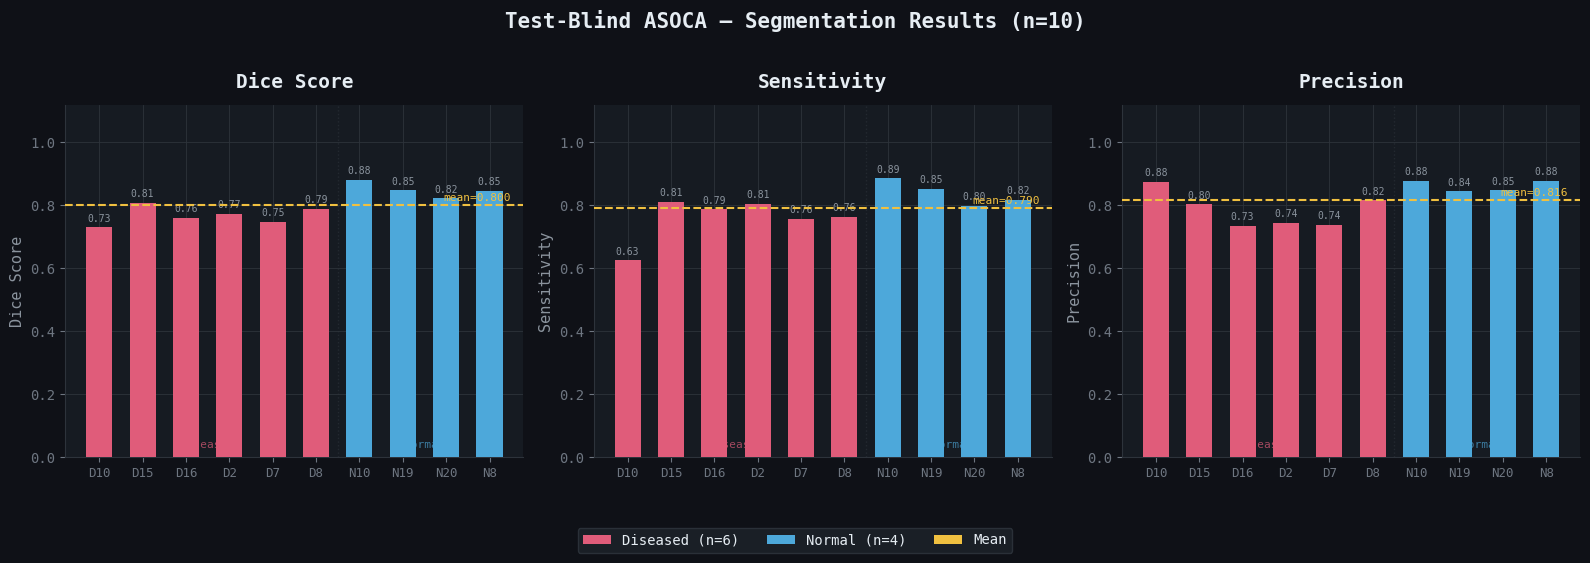

Guardada: metrics_testblind.png


In [21]:
# ── Celda 7 reemplazada: Gráfica métricas ─────────────────────────
S = TESIS_STYLE
metrics_plot = ['dice', 'sensitivity', 'precision']
titles       = ['Dice Score', 'Sensitivity', 'Precision']

# Separar por grupo para ordenar mejor
df_sorted = pd.concat([
    df[df['type']=='diseased'].sort_values('case_id'),
    df[df['type']=='normal'].sort_values('case_id')
]).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.patch.set_facecolor(S['bg_fig'])

for ax, metric, title in zip(axes, metrics_plot, titles):

    x      = range(len(df_sorted))
    colors = [S['col_diseased'] if t=='diseased'
              else S['col_normal'] for t in df_sorted['type']]
    values = df_sorted[metric].values

    bars = ax.bar(x, values, color=colors, width=0.6,
                  zorder=3, linewidth=0)

    # Valor encima de cada barra
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f'{val:.2f}',
                ha='center', va='bottom',
                color=S['col_label'],
                fontsize=7)

    # Línea de media
    mean_val = values.mean()
    ax.axhline(mean_val, color=S['col_mean'],
               linestyle='--', linewidth=1.5, zorder=4)
    ax.text(len(df_sorted) - 0.5, mean_val + 0.015,
            f'mean={mean_val:.3f}',
            ha='right', color=S['col_mean'], fontsize=8)

    # Separador diseased / normal
    ax.axvline(5.5, color=S['col_spine'],
               linestyle=':', linewidth=1, alpha=0.6)
    ax.text(2.5, 0.03, 'Diseased', ha='center',
            color=S['col_diseased'], fontsize=8, alpha=0.7)
    ax.text(7.5, 0.03, 'Normal', ha='center',
            color=S['col_normal'], fontsize=8, alpha=0.7)

    ax.set_title(title, color=S['col_title'],
                 fontsize=S['font_title'], fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [c.replace('asoca_diseased_','D').replace('asoca_normal_','N')
         for c in df_sorted['case_id']],
        rotation=0, fontsize=S['font_tick']
    )
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(title, color=S['col_label'], fontsize=S['font_label'])

# Leyenda global
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=S['col_diseased'], label='Diseased (n=6)'),
    Patch(facecolor=S['col_normal'],   label='Normal (n=4)'),
    mpatches.Patch(facecolor=S['col_mean'], label='Mean'),
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Test-Blind ASOCA — Segmentation Results (n=10)',
             color=S['col_title'],
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(OUT_DIR, 'metrics_testblind.png'),
            dpi=150, bbox_inches='tight',
            facecolor=S['bg_fig'])
plt.show()
print('Guardada: metrics_testblind.png')

Visualizando mejor caso: asoca_normal_10 (Dice=0.8815)


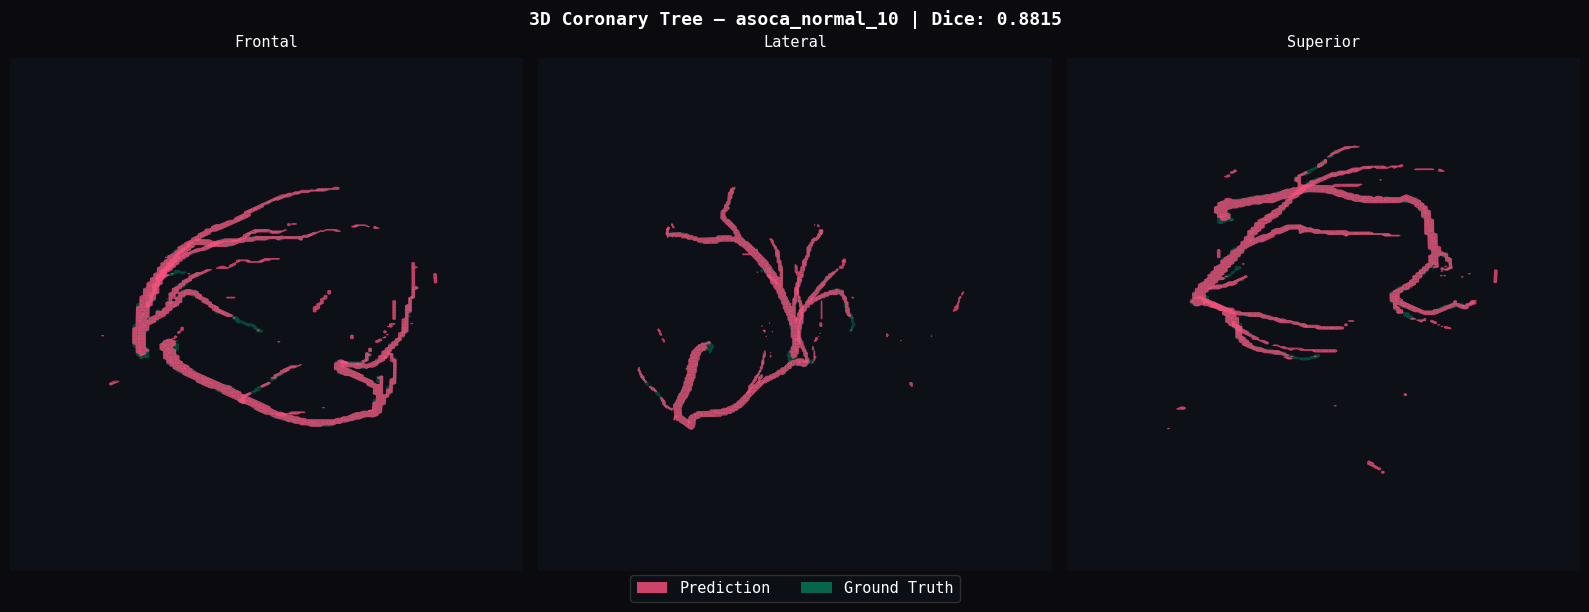

Guardada: 3d_tree_asoca_normal_10.png


In [22]:
# ── Celda 8: Visualización 3D árbol coronario ─────────────────────
# Elige el caso con mejor Dice para visualización
best_case = df.loc[df['dice'].idxmax(), 'case_id']
print(f'Visualizando mejor caso: {best_case} '
      f'(Dice={df.loc[df["case_id"]==best_case, "dice"].values[0]:.4f})')

pred_bin = predictions[best_case]['pred']
mask_gt  = predictions[best_case]['gt']

# Downsample para visualización (marching cubes más rápido)
scale = 0.5
pred_ds = zoom(pred_bin.astype(np.float32), scale, order=0)
gt_ds   = zoom(mask_gt.astype(np.float32),  scale, order=0)

# Extraer superficie con marching cubes
def get_surface(mask_3d, level=0.5):
    if mask_3d.sum() < 10:
        return None, None
    try:
        verts, faces, _, _ = marching_cubes(mask_3d, level=level)
        return verts, faces
    except:
        return None, None

verts_pred, faces_pred = get_surface(pred_ds)
verts_gt,   faces_gt   = get_surface(gt_ds)

# ─── Plot 3D ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('#0a0a0f')

views = [('Frontal', 0, 90), ('Lateral', 0, 0), ('Superior', 90, 90)]

for idx, (view_name, elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    ax.set_facecolor('#0d1117')

    # Ground truth (verde translúcido)
    if verts_gt is not None:
        mesh_gt = Poly3DCollection(verts_gt[faces_gt], alpha=0.15,
                                    facecolor='#00e5a0', edgecolor='none')
        ax.add_collection3d(mesh_gt)

    # Predicción (rojo/coral)
    if verts_pred is not None:
        mesh_pred = Poly3DCollection(verts_pred[faces_pred], alpha=0.6,
                                      facecolor='#ff5080', edgecolor='none')
        ax.add_collection3d(mesh_pred)

    # Ejes
    if verts_pred is not None:
        ax.set_xlim(verts_pred[:,0].min(), verts_pred[:,0].max())
        ax.set_ylim(verts_pred[:,1].min(), verts_pred[:,1].max())
        ax.set_zlim(verts_pred[:,2].min(), verts_pred[:,2].max())

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(view_name, color='white', fontsize=11, pad=8)
    ax.set_axis_off()

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff5080', alpha=0.8, label='Prediction'),
    Patch(facecolor='#00e5a0', alpha=0.4, label='Ground Truth'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           facecolor='#0d1117', edgecolor='#333',
           labelcolor='white', fontsize=11, bbox_to_anchor=(0.5, -0.02))

dice_val = df.loc[df['case_id']==best_case, 'dice'].values[0]
fig.suptitle(f'3D Coronary Tree — {best_case} | Dice: {dice_val:.4f}',
             color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'3d_tree_{best_case}.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print(f'Guardada: 3d_tree_{best_case}.png')

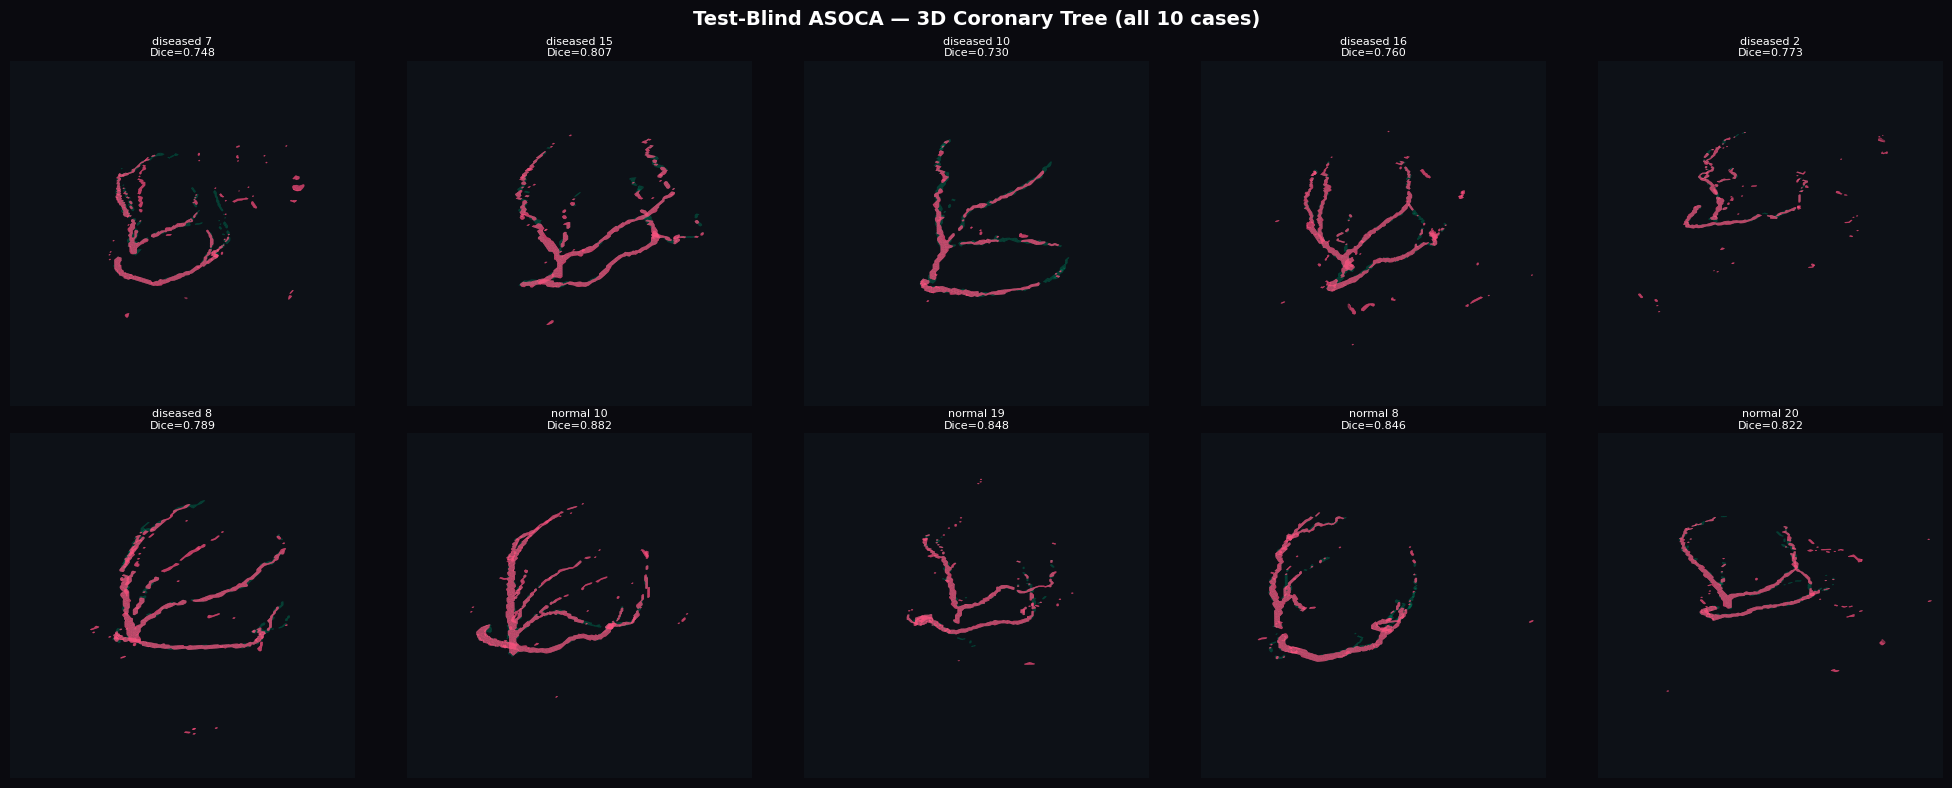

Guardada: all_cases_3d.png


In [12]:
# ── Celda 9: Visualizar todos los casos 3D ────────────────────────
# Grid con los 10 casos (vista frontal)
fig, axes_grid = plt.subplots(2, 5, figsize=(20, 8),
                               subplot_kw={'projection': '3d'})
fig.patch.set_facecolor('#0a0a0f')

for ax, case_id in zip(axes_grid.flatten(), test_cases):
    ax.set_facecolor('#0d1117')
    pred_b = predictions[case_id]['pred']
    gt_b   = predictions[case_id]['gt']

    pred_ds = zoom(pred_b.astype(np.float32), 0.3, order=0)
    gt_ds   = zoom(gt_b.astype(np.float32),   0.3, order=0)

    v_gt, f_gt   = get_surface(gt_ds)
    v_pr, f_pr   = get_surface(pred_ds)

    if v_gt is not None:
        ax.add_collection3d(Poly3DCollection(v_gt[f_gt], alpha=0.12,
                            facecolor='#00e5a0', edgecolor='none'))
    if v_pr is not None:
        ax.add_collection3d(Poly3DCollection(v_pr[f_pr], alpha=0.55,
                            facecolor='#ff5080', edgecolor='none'))
        ax.set_xlim(v_pr[:,0].min(), v_pr[:,0].max())
        ax.set_ylim(v_pr[:,1].min(), v_pr[:,1].max())
        ax.set_zlim(v_pr[:,2].min(), v_pr[:,2].max())

    dice_v = df.loc[df['case_id']==case_id, 'dice'].values[0]
    t = case_id.replace('asoca_','').replace('_',' ')
    ax.set_title(f'{t}\nDice={dice_v:.3f}',
                 color='white', fontsize=8, pad=4)
    ax.view_init(elev=20, azim=45)
    ax.set_axis_off()

fig.suptitle('Test-Blind ASOCA — 3D Coronary Tree (all 10 cases)',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'all_cases_3d.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print('Guardada: all_cases_3d.png')

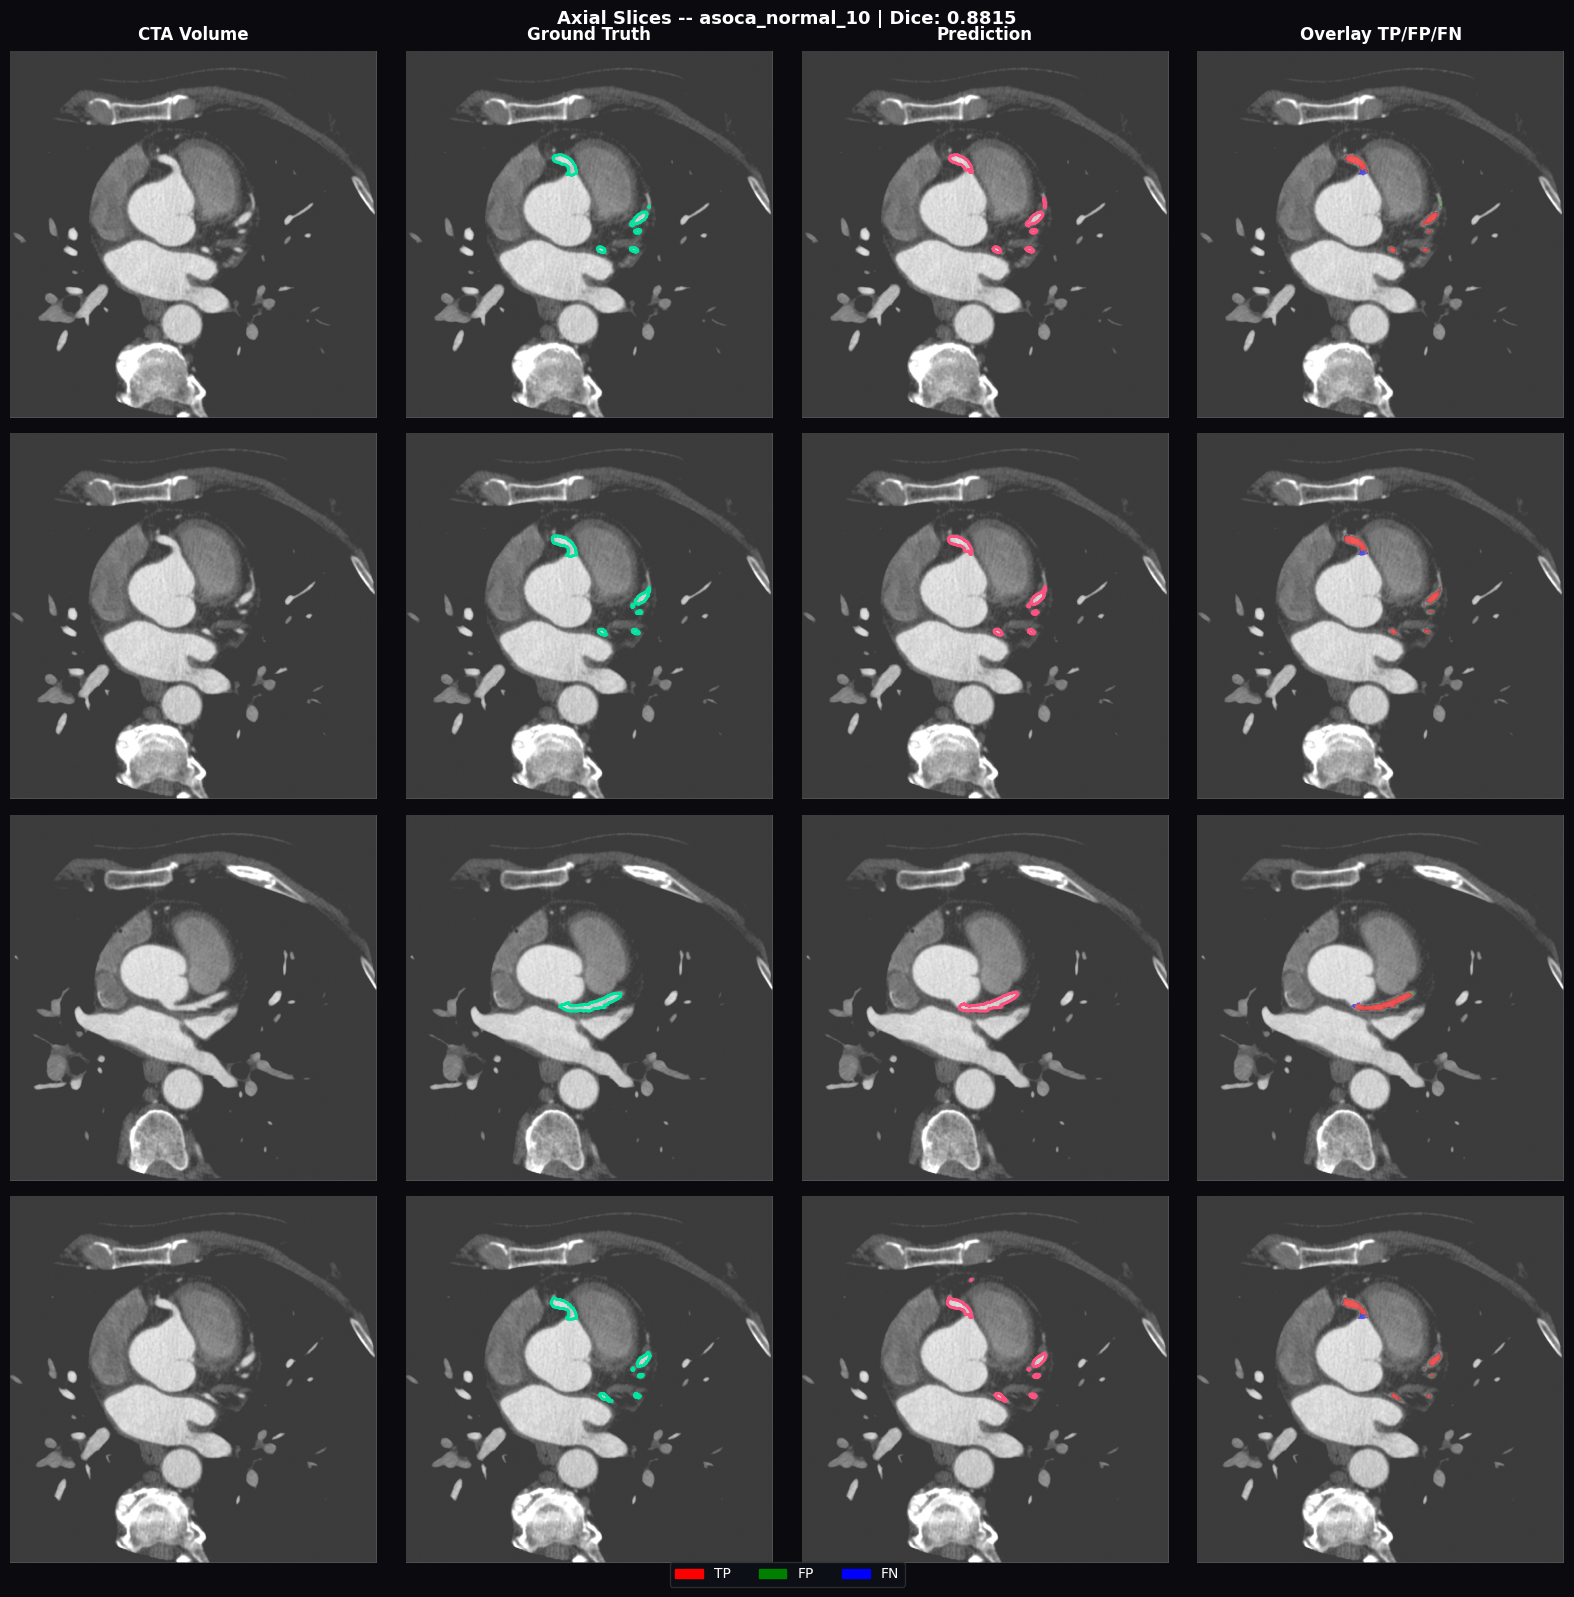

Guardada: slices_asoca_normal_10.png


In [14]:
# ── Celda 10: Comparación de slices axiales ───────────────────────
case_id = best_case
vol     = predictions[case_id]['vol']
gt      = predictions[case_id]['gt']
pred    = predictions[case_id]['pred']
prob    = predictions[case_id]['prob']

gt_per_slice = gt.sum(axis=(1,2))
top_slices   = np.argsort(gt_per_slice)[-4:][::-1]

fig, axes_s = plt.subplots(4, 4, figsize=(16, 16))
fig.patch.set_facecolor('#0a0a0f')
col_titles = ['CTA Volume', 'Ground Truth', 'Prediction', 'Overlay TP/FP/FN']

for col, title in enumerate(col_titles):
    axes_s[0, col].set_title(title, color='white', fontsize=12,
                              fontweight='bold', pad=8)

for row, sl in enumerate(top_slices):
    v_sl  = vol[sl]
    gt_sl = gt[sl].astype(bool)
    pr_sl = pred[sl].astype(bool)

    axes_s[row,0].imshow(v_sl, cmap='gray', vmin=-2, vmax=4)
    axes_s[row,0].set_ylabel(f'Slice {sl}', color='gray', fontsize=9)

    axes_s[row,1].imshow(v_sl, cmap='gray', vmin=-2, vmax=4)
    axes_s[row,1].contour(gt_sl.astype(np.float32), colors=['#00e5a0'], linewidths=1.5)

    axes_s[row,2].imshow(v_sl, cmap='gray', vmin=-2, vmax=4)
    axes_s[row,2].contour(pr_sl.astype(np.float32), colors=['#ff5080'], linewidths=1.5)

    # Overlay TP/FP/FN como imagen RGBA float32
    tp_mask = np.logical_and(pr_sl, gt_sl).astype(np.float32)
    fp_mask = np.logical_and(pr_sl, ~gt_sl).astype(np.float32)
    fn_mask = np.logical_and(~pr_sl, gt_sl).astype(np.float32)

    axes_s[row,3].imshow(v_sl, cmap='gray', vmin=-2, vmax=4)

    H, W = v_sl.shape
    tp_rgba = np.zeros((H, W, 4), dtype=np.float32)
    tp_rgba[..., 0] = tp_mask; tp_rgba[..., 3] = tp_mask * 0.6
    axes_s[row,3].imshow(tp_rgba)

    fp_rgba = np.zeros((H, W, 4), dtype=np.float32)
    fp_rgba[..., 1] = fp_mask; fp_rgba[..., 3] = fp_mask * 0.6
    axes_s[row,3].imshow(fp_rgba)

    fn_rgba = np.zeros((H, W, 4), dtype=np.float32)
    fn_rgba[..., 2] = fn_mask; fn_rgba[..., 3] = fn_mask * 0.6
    axes_s[row,3].imshow(fn_rgba)

    for ax in axes_s[row]:
        ax.set_facecolor('#0d1117')
        ax.axis('off')

from matplotlib.patches import Patch
leg = [Patch(color='red',   label='TP'),
       Patch(color='green', label='FP'),
       Patch(color='blue',  label='FN')]
fig.legend(handles=leg, loc='lower center', ncol=3,
           facecolor='#0d1117', edgecolor='#333333',
           labelcolor='white', fontsize=10, bbox_to_anchor=(0.5, -0.01))

dice_v = df.loc[df['case_id']==case_id, 'dice'].values[0]
fig.suptitle(f'Axial Slices -- {case_id} | Dice: {dice_v:.4f}',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'slices_{case_id}.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print(f'Guardada: slices_{case_id}.png')

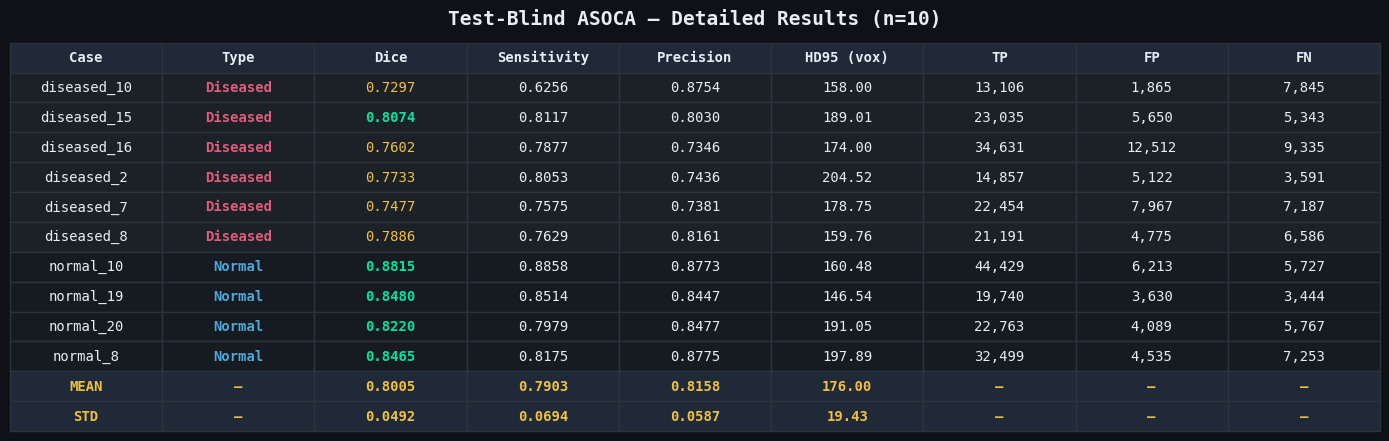

In [24]:
# ── Tabla detallada de resultados ─────────────────────────────────
S = TESIS_STYLE

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(S['bg_fig'])
ax.set_facecolor(S['bg_fig'])
ax.axis('off')

# Datos
cols = ['Case', 'Type', 'Dice', 'Sensitivity', 'Precision', 'HD95 (vox)',
        'TP', 'FP', 'FN']

rows = []
for _, row in df_sorted.iterrows():
    pred = predictions[row['case_id']]['pred'].astype(bool)
    gt   = predictions[row['case_id']]['gt'].astype(bool)
    tp   = int(np.logical_and(pred, gt).sum())
    fp   = int(np.logical_and(pred, ~gt).sum())
    fn   = int(np.logical_and(~pred, gt).sum())
    rows.append([
        row['case_id'].replace('asoca_', ''),
        row['type'].capitalize(),
        f"{row['dice']:.4f}",
        f"{row['sensitivity']:.4f}",
        f"{row['precision']:.4f}",
        f"{row['hd95']:.2f}",
        f"{tp:,}",
        f"{fp:,}",
        f"{fn:,}",
    ])

# Fila de medias
m = df_sorted[['dice','sensitivity','precision','hd95']].mean()
rows.append([
    'MEAN', '—',
    f"{m['dice']:.4f}",
    f"{m['sensitivity']:.4f}",
    f"{m['precision']:.4f}",
    f"{m['hd95']:.2f}",
    '—', '—', '—'
])

# Fila de std
s = df_sorted[['dice','sensitivity','precision','hd95']].std()
rows.append([
    'STD', '—',
    f"{s['dice']:.4f}",
    f"{s['sensitivity']:.4f}",
    f"{s['precision']:.4f}",
    f"{s['hd95']:.2f}",
    '—', '—', '—'
])

table = ax.table(
    cellText=rows,
    colLabels=cols,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Estilo por fila
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor(S['col_grid'])

    # Header
    if row_idx == 0:
        cell.set_facecolor('#1f2937')
        cell.set_text_props(color=S['col_title'], fontweight='bold')

    # Media y std (ultimas 2 filas)
    elif row_idx >= len(rows) - 1:
        cell.set_facecolor('#1f2937')
        cell.set_text_props(color=S['col_mean'], fontweight='bold')

    # Diseased
    elif rows[row_idx-1][1] == 'Diseased':
        cell.set_facecolor(S['bg_panel'])
        cell.set_text_props(color=S['col_title'])
        # Colorear columna Type
        if col_idx == 1:
            cell.set_text_props(color=S['col_diseased'], fontweight='bold')

    # Normal
    else:
        cell.set_facecolor(S['bg_ax'])
        cell.set_text_props(color=S['col_title'])
        if col_idx == 1:
            cell.set_text_props(color=S['col_normal'], fontweight='bold')

    # Colorear columna Dice por valor
    if col_idx == 2 and row_idx > 0 and row_idx <= len(df_sorted):
        try:
            val = float(rows[row_idx-1][2])
            if val >= 0.80:
                cell.set_text_props(color='#00e5a0', fontweight='bold')
            elif val >= 0.70:
                cell.set_text_props(color=S['col_mean'])
            else:
                cell.set_text_props(color=S['col_diseased'])
        except:
            pass

ax.set_title('Test-Blind ASOCA — Detailed Results (n=10)',
             color=S['col_title'], fontsize=14,
             fontweight='bold', pad=40)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(OUT_DIR, 'results_table.png'),
            dpi=150, bbox_inches='tight', facecolor=S['bg_fig'])
plt.show()

In [25]:
# ── Celda 11: Resumen final ───────────────────────────────────────
print('\n╔══════════════════════════════════════════════════════════╗')
print('║         RESUMEN EVALUACIÓN TEST-BLIND ASOCA              ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Modelo:       {os.path.basename(os.path.dirname(CKPT_PATH)):<42}║')
print(f'║  Checkpoint:   época {best_epoch:<38}║')
print(f'║  Casos:        {len(test_cases)} (6 diseased + 4 normal){" "*17}║')
print('╠══════════════════════════════════════════════════════════╣')
m = df[['dice','sensitivity','precision','hd95']].mean()
s = df[['dice','sensitivity','precision','hd95']].std()
print(f'║  Dice:         {m["dice"]:.4f} ± {s["dice"]:.4f}{" "*29}║')
print(f'║  Sensitivity:  {m["sensitivity"]:.4f} ± {s["sensitivity"]:.4f}{" "*29}║')
print(f'║  Precision:    {m["precision"]:.4f} ± {s["precision"]:.4f}{" "*29}║')
print(f'║  HD95 (vox):   {m["hd95"]:.2f} ± {s["hd95"]:.2f}{" "*32}║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Archivos guardados en:                                  ║')
print(f'║  {OUT_DIR:<56}║')
print('╚══════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════╗
║         RESUMEN EVALUACIÓN TEST-BLIND ASOCA              ║
╠══════════════════════════════════════════════════════════╣
║  Modelo:       seg_20260307_1329                         ║
║  Checkpoint:   época ?                                     ║
║  Casos:        10 (6 diseased + 4 normal)                 ║
╠══════════════════════════════════════════════════════════╣
║  Dice:         0.8005 ± 0.0492                             ║
║  Sensitivity:  0.7903 ± 0.0694                             ║
║  Precision:    0.8158 ± 0.0587                             ║
║  HD95 (vox):   176.00 ± 19.43                                ║
╠══════════════════════════════════════════════════════════╣
║  Archivos guardados en:                                  ║
║  /media/mrsmile/IA/tesis/reportes/evaluation             ║
╚══════════════════════════════════════════════════════════╝
